# Tema 2: **Predição de Aprovação de Acesso a Recursos**

**Área de atuação:** Classificação Binária Supervisionada.

**Descrição:** Desenvolvimento de um classificador para prever um de dois resultados possíveis (acesso concedido ou negado), com foco no tratamento de dados desbalanceados para garantir um modelo robusto e justo.

**Requisitos específicos:**
1.  Realizar uma análise exploratória detalhada para identificar correlações, distribuições e a presença de outliers.
2.  Investigar e aplicar uma estratégia para tratar dados faltantes, justificando a escolha do método.
3.  Analisar o balanceamento entre as classes. Aplicar ao menos uma técnica de reamostragem (como SMOTE ou Random Undersampling) e comparar os resultados do modelo com e sem a aplicação da técnica.
4.  Avaliar os modelos utilizando no mínimo 3 métricas de avaliação adequadas para classificação binária, especialmente em cenários desbalanceados (ex: Acurácia, Precisão, Recall, F1-Score, e AUC-ROC).

**Fase inicial: Business Understanding**

-   **Problema de Negócio**: Prever se um funcionário da Amazon terá acesso ou não a recursos específicos.
-   **Tipo**: Classificação Binária Supervisionada
-   **Variável Alvo (Target)**: `ACTION` (1 = acesso concedido; 0 = acesso negado)
-   **Métricas de Avaliação**: Acurácia, Precisão, Recall, F1-Score e AUC-ROC

## **0. Configurações Iniciais**

**Análise de Tratamento de Dados:**

Nesta seção, realizaremos uma análise exploratória detalhada para:
*   Identificar e tratar valores faltantes e duplicatas.
*   Analisar a distribuição dos dados e identificar possíveis outliers.
*   Verificar o desbalanceamento das classes na variável alvo.
*   Realizar o pré-processamento dos dados, incluindo a conversão de features categóricas para numéricas, análise de correlações e, se necessário, normalização.
*   Separar os dados em conjuntos de treino, validação e teste de forma estratificada para manter a proporção das classes.

### Instalações, imports e configurações


In [30]:
# Se alguma biblioteca estiver faltando no Colab, descomente a linha abaixo:
# !pip -q install imbalanced-learn

In [31]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import normalized_mutual_info_score
from sklearn.naive_bayes import BernoulliNB

from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "ACTION"
MISSING_TOKEN = "__MISSING__"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("default")

### Carregamento dos dados

O arquivo esperado é `train.csv`, da base **Amazon Employee Access Challenge**.  
No Colab, envie o arquivo para `/content/train.csv` ou ajuste a variável `DATA_PATH`.


In [32]:
possible_paths = [
    Path("/content/train.csv"),
    Path("train.csv"),
    Path("/mnt/data/train.csv"),
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Arquivo train.csv não encontrado. Envie o dataset para o Colab ou ajuste DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print(f"Arquivo carregado: {DATA_PATH}")
print(f"Dimensões da base: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas")
df.head()

Arquivo carregado: /content/train.csv
Dimensões da base: 32,769 linhas x 10 colunas


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


In [33]:
# checagem do Target
if TARGET_COL not in df.columns:
    raise ValueError(f"A coluna alvo '{TARGET_COL}' não foi encontrada no dataset.")

print("Valores únicos da variável alvo:", sorted(df[TARGET_COL].dropna().unique()))
print("Tipos das colunas:")
display(df.dtypes.to_frame("tipo"))


Valores únicos da variável alvo: [np.int64(0), np.int64(1)]
Tipos das colunas:


,tipo
ACTION,int64
RESOURCE,int64
MGR_ID,int64
ROLE_ROLLUP_1,int64
ROLE_ROLLUP_2,int64
ROLE_DEPTNAME,int64
ROLE_TITLE,int64
ROLE_FAMILY_DESC,int64
ROLE_FAMILY,int64
ROLE_CODE,int64


### Dicionário das variáveis

Na base original, as variáveis explicativas são identificadores categóricos. Mesmo quando aparecem como números, elas **não devem ser interpretadas como grandezas numéricas contínuas**. Por exemplo, `RESOURCE = 1000` não significa necessariamente algo menor ou mais próximo de `RESOURCE = 1001`.

Por isso, o pré-processamento oficial deste notebook usa codificação categórica (`OneHotEncoder`) em vez de `LabelEncoder` simples.


In [34]:
data_dictionary = pd.DataFrame({
    "variavel": df.columns,
    "papel": ["target" if col == TARGET_COL else "feature categórica" for col in df.columns],
    "descricao": [
        "1 = acesso concedido; 0 = acesso negado" if col == TARGET_COL
        else "Identificador categórico associado à solicitação de acesso"
        for col in df.columns
    ],
    "valores_unicos": [df[col].nunique(dropna=False) for col in df.columns],
})

display(data_dictionary)


,variavel,papel,descricao,valores_unicos
0,ACTION,target,1 = acesso concedido; 0 = acesso negado,2
1,RESOURCE,feature categórica,Identificador categórico associado à solicitaç...,7518
2,MGR_ID,feature categórica,Identificador categórico associado à solicitaç...,4243
3,ROLE_ROLLUP_1,feature categórica,Identificador categórico associado à solicitaç...,128
4,ROLE_ROLLUP_2,feature categórica,Identificador categórico associado à solicitaç...,177
5,ROLE_DEPTNAME,feature categórica,Identificador categórico associado à solicitaç...,449
6,ROLE_TITLE,feature categórica,Identificador categórico associado à solicitaç...,343
7,ROLE_FAMILY_DESC,feature categórica,Identificador categórico associado à solicitaç...,2358
8,ROLE_FAMILY,feature categórica,Identificador categórico associado à solicitaç...,67
9,ROLE_CODE,feature categórica,Identificador categórico associado à solicitaç...,343


## **1. Data Understanding**

Esta seção verifica pontos exigidos pelo projeto: valores faltantes, duplicatas, distribuição das classes, alta cardinalidade, categorias raras, associações entre variáveis e presença de possíveis outliers.


In [35]:
summary = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique(dropna=False).values,
    "faltantes": df.isna().sum().values,
    "percentual_faltantes": (df.isna().mean() * 100).round(4).values,
})

display(summary)
print(f"Quantidade de linhas duplicadas: {df.duplicated().sum():,}")


,coluna,tipo,valores_unicos,faltantes,percentual_faltantes
0,ACTION,int64,2,0,0.0
1,RESOURCE,int64,7518,0,0.0
2,MGR_ID,int64,4243,0,0.0
3,ROLE_ROLLUP_1,int64,128,0,0.0
4,ROLE_ROLLUP_2,int64,177,0,0.0
5,ROLE_DEPTNAME,int64,449,0,0.0
6,ROLE_TITLE,int64,343,0,0.0
7,ROLE_FAMILY_DESC,int64,2358,0,0.0
8,ROLE_FAMILY,int64,67,0,0.0
9,ROLE_CODE,int64,343,0,0.0


Quantidade de linhas duplicadas: 0


### Estratégia para dados faltantes

A checagem acima indica se há valores faltantes no dataset. Como a base da Amazon Employee Access Challenge não apresenta dados faltantes nativos no carregamento atual, não foi necessário remover linhas ou aplicar imputações estatísticas.

Mesmo assim, o pipeline de pré-processamento mantém uma etapa de imputação com o token `__MISSING__`. Essa decisão é importante porque:

- os atributos são identificadores categóricos, não medidas contínuas;
- imputar média ou mediana criaria valores sem interpretação real;
- uma categoria explícita para ausência preserva a natureza categórica dos dados;
- o pipeline continua robusto caso novos registros venham com campos ausentes.

,classe,quantidade,percentual
0,1,30872,94.21
1,0,1897,5.79


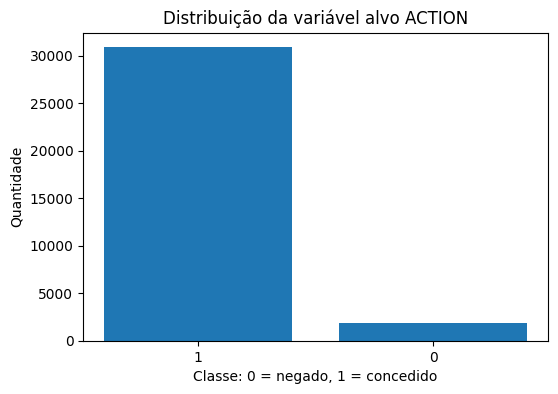

In [36]:
target_distribution = (
    df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)
target_distribution["percentual"] = (
    target_distribution["quantidade"] / len(df) * 100
).round(2)

display(target_distribution)

plt.figure(figsize=(6, 4))
plt.bar(target_distribution["classe"].astype(str), target_distribution["quantidade"])
plt.title("Distribuição da variável alvo ACTION")
plt.xlabel("Classe: 0 = negado, 1 = concedido")
plt.ylabel("Quantidade")
plt.show()


### Cardinalidade

,feature,valores_unicos,percentual_unicos
0,RESOURCE,7518,22.94
1,MGR_ID,4243,12.95
6,ROLE_FAMILY_DESC,2358,7.20
4,ROLE_DEPTNAME,449,1.37
5,ROLE_TITLE,343,1.05
8,ROLE_CODE,343,1.05
3,ROLE_ROLLUP_2,177,0.54
2,ROLE_ROLLUP_1,128,0.39
7,ROLE_FAMILY,67,0.20


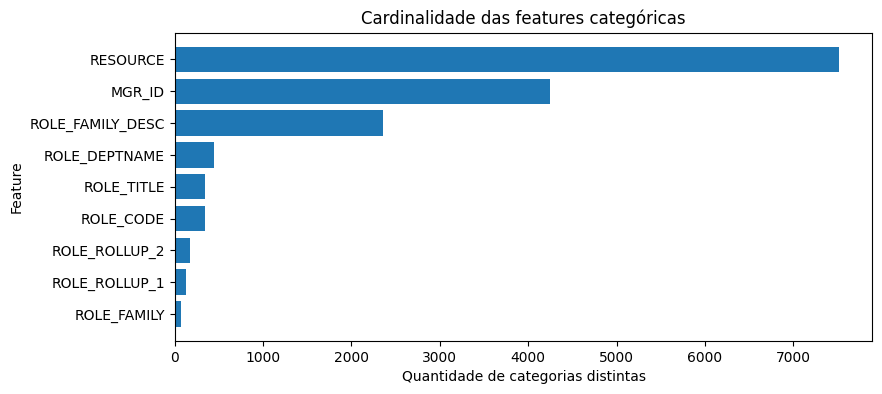

In [37]:
feature_cols = [col for col in df.columns if col != TARGET_COL]

cardinality = pd.DataFrame({
    "feature": feature_cols,
    "valores_unicos": [df[col].nunique(dropna=False) for col in feature_cols],
    "percentual_unicos": [(df[col].nunique(dropna=False) / len(df) * 100) for col in feature_cols],
}).sort_values("valores_unicos", ascending=False)

cardinality["percentual_unicos"] = cardinality["percentual_unicos"].round(2)
display(cardinality)

plt.figure(figsize=(9, 4))
plt.barh(cardinality["feature"], cardinality["valores_unicos"])
plt.gca().invert_yaxis()
plt.title("Cardinalidade das features categóricas")
plt.xlabel("Quantidade de categorias distintas")
plt.ylabel("Feature")
plt.show()


In [38]:
def rare_category_report(data, columns, min_count=10):
    rows = []
    for col in columns:
        counts = data[col].value_counts(dropna=False)
        rare_mask = counts < min_count
        rows.append({
            "feature": col,
            "categorias_total": counts.shape[0],
            f"categorias_com_menos_de_{min_count}_ocorrencias": int(rare_mask.sum()),
            "percentual_categorias_raras": round(rare_mask.mean() * 100, 2),
            "linhas_em_categorias_raras": int(counts[rare_mask].sum()),
            "percentual_linhas_raras": round(counts[rare_mask].sum() / len(data) * 100, 2),
        })
    return pd.DataFrame(rows).sort_values("percentual_linhas_raras", ascending=False)

rare_report = rare_category_report(df, feature_cols, min_count=10)
display(rare_report)


,feature,categorias_total,categorias_com_menos_de_10_ocorrencias,percentual_categorias_raras,linhas_em_categorias_raras,percentual_linhas_raras
0,RESOURCE,7518,7009,93.23,14801,45.17
1,MGR_ID,4243,3179,74.92,10913,33.30
6,ROLE_FAMILY_DESC,2358,1889,80.11,5790,17.67
5,ROLE_TITLE,343,129,37.61,510,1.56
8,ROLE_CODE,343,129,37.61,510,1.56
4,ROLE_DEPTNAME,449,120,26.73,480,1.46
3,ROLE_ROLLUP_2,177,43,24.29,157,0.48
2,ROLE_ROLLUP_1,128,23,17.97,75,0.23
7,ROLE_FAMILY,67,17,25.37,75,0.23


### Outliers

Como as features são identificadores categóricos, o comportamento mais próximo de outlier é a presença de **categorias raras**, isto é, valores que aparecem poucas vezes e podem dificultar a generalização do modelo.

Por isso, a análise de outliers foi adaptada para:

- identificar categorias com baixa frequência;
- avaliar concentração das categorias mais comuns;
- verificar categorias associadas a maior taxa de negação;
- agrupar categorias muito raras no `OneHotEncoder` usando `min_frequency`.

In [39]:
def target_rate_by_feature(data, feature, target=TARGET_COL, top_n=10):
    tmp = (
        data.groupby(feature)[target]
        .agg(quantidade="count", taxa_concessao="mean")
        .reset_index()
        .sort_values("quantidade", ascending=False)
        .head(top_n)
    )
    tmp["taxa_negacao"] = 1 - tmp["taxa_concessao"]
    return tmp

for col in feature_cols:
    display_col = target_rate_by_feature(df, col, top_n=10)
    print(f"\nFeature: {col}")
    display(display_col)



Feature: RESOURCE


,RESOURCE,quantidade,taxa_concessao,taxa_negacao
194,4675,839,0.996424,0.003576
5566,79092,484,0.966942,0.033058
4936,75078,409,0.990220,0.009780
1329,25993,409,0.953545,0.046455
182,3853,404,0.985149,0.014851
5065,75834,299,0.983278,0.016722
314,6977,299,0.946488,0.053512
1987,32270,295,0.945763,0.054237
3506,42085,247,0.959514,0.040486
651,17308,239,0.987448,0.012552



Feature: MGR_ID


,MGR_ID,quantidade,taxa_concessao,taxa_negacao
62,770,152,0.967105,0.032895
261,2270,99,0.969697,0.030303
311,2594,82,0.865854,0.134146
123,1350,71,0.943662,0.056338
220,2014,67,1.000000,0.000000
1811,16850,66,0.954545,0.045455
1209,7807,64,0.906250,0.093750
527,3966,64,0.984375,0.015625
867,5396,62,1.000000,0.000000
449,3526,62,0.967742,0.032258



Feature: ROLE_ROLLUP_1


...

,ROLE_FAMILY_DESC,quantidade,taxa_concessao,taxa_negacao
7,117906,6896,0.933440,0.066560
1901,240983,1244,0.955788,0.044212
8,117913,670,0.968657,0.031343
2143,279443,665,0.924812,0.075188
3,117886,530,0.901887,0.098113
599,130134,419,0.966587,0.033413
4,117897,351,0.888889,0.111111
2,117879,333,0.954955,0.045045
1402,168365,324,0.956790,0.043210
739,133686,321,0.993769,0.006231



Feature: ROLE_FAMILY


,ROLE_FAMILY,quantidade,taxa_concessao,taxa_negacao
64,290919,10980,0.942350,0.057650
14,118424,2690,0.972491,0.027509
3,19721,2636,0.907815,0.092185
5,117887,2400,0.959167,0.040833
65,292795,1318,0.862671,0.137329
13,118398,1294,0.952087,0.047913
66,308574,1287,0.947941,0.052059
15,118453,941,0.965994,0.034006
9,118331,892,0.942825,0.057175
22,118643,783,0.970626,0.029374



Feature: ROLE_CODE


,ROLE_CODE,quantidade,taxa_concessao,taxa_negacao
23,118322,4649,0.920413,0.079587
4,117908,3583,0.967625,0.032375
51,118786,1772,0.929458,0.070542
0,117880,1256,0.889331,0.110669
40,118570,1043,0.925216,0.074784
1,117888,806,0.967742,0.032258
11,118055,774,0.970284,0.029716
44,118687,597,0.974874,0.025126
50,118779,566,0.915194,0.084806
29,118454,521,0.967370,0.032630


,feature,cramers_v_com_ACTION
1,MGR_ID,0.4540
0,RESOURCE,0.3065
6,ROLE_FAMILY_DESC,0.2986
4,ROLE_DEPTNAME,0.2642
5,ROLE_TITLE,0.1816
8,ROLE_CODE,0.1816
3,ROLE_ROLLUP_2,0.1745
2,ROLE_ROLLUP_1,0.1393
7,ROLE_FAMILY,0.1223


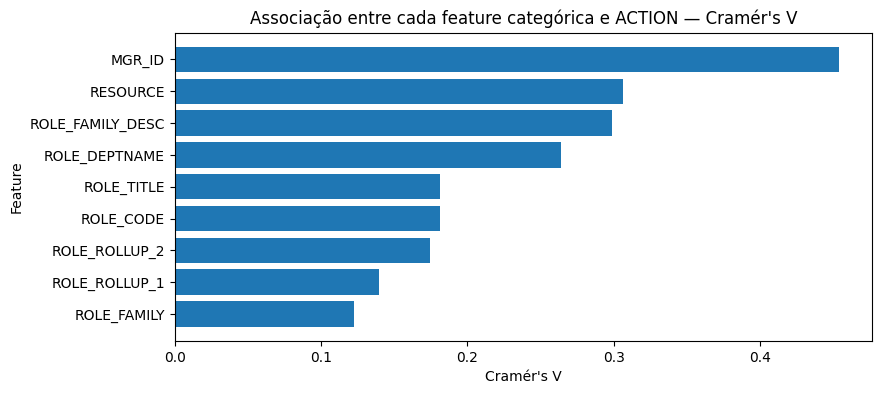

In [40]:
def cramers_v_feature_target(data, feature, target=TARGET_COL):
    table = pd.crosstab(data[feature], data[target])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    # Correção de viés para Cramér's V
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(k_corr - 1, r_corr - 1)
    if denominator <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denominator)

association_target = pd.DataFrame({
    "feature": feature_cols,
    "cramers_v_com_ACTION": [cramers_v_feature_target(df, col) for col in feature_cols],
}).sort_values("cramers_v_com_ACTION", ascending=False)

association_target["cramers_v_com_ACTION"] = association_target["cramers_v_com_ACTION"].round(4)
display(association_target)

plt.figure(figsize=(9, 4))
plt.barh(association_target["feature"], association_target["cramers_v_com_ACTION"])
plt.gca().invert_yaxis()
plt.title("Associação entre cada feature categórica e ACTION — Cramér's V")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.show()


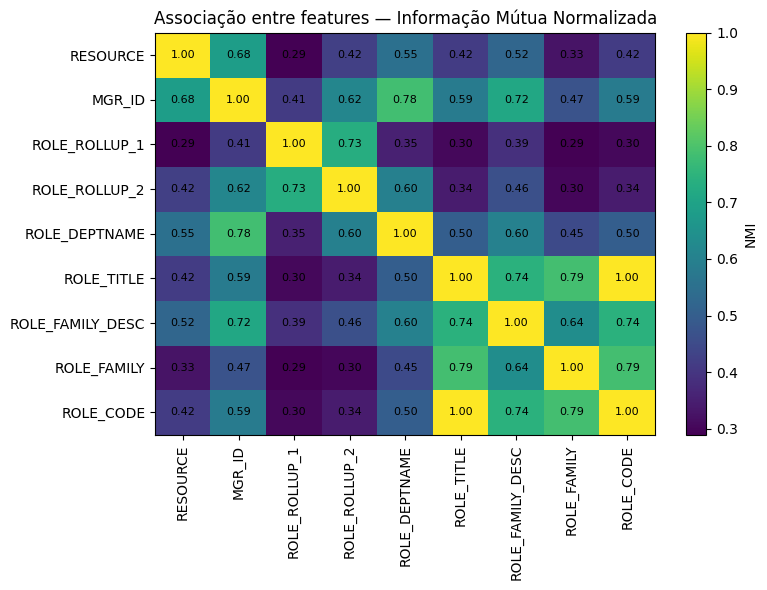

In [41]:
# @title Correlação

nmi_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)

for col_a in feature_cols:
    for col_b in feature_cols:
        nmi_matrix.loc[col_a, col_b] = normalized_mutual_info_score(
            df[col_a].astype(str),
            df[col_b].astype(str),
        )

plt.figure(figsize=(8, 6))
plt.imshow(nmi_matrix.astype(float), aspect="auto")
plt.colorbar(label="NMI")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        plt.text(j, i, f"{nmi_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Associação entre features — Informação Mútua Normalizada")
plt.tight_layout()
plt.show()


### Separação em treino, validação e teste

A divisão é estratificada para preservar a proporção entre acessos concedidos e negados em todos os conjuntos.


In [42]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "amostras": [len(y_train), len(y_valid), len(y_test)],
    "percentual_classe_0_negado": [
        (y_train.eq(0).mean() * 100).round(2),
        (y_valid.eq(0).mean() * 100).round(2),
        (y_test.eq(0).mean() * 100).round(2),
    ],
    "percentual_classe_1_concedido": [
        (y_train.eq(1).mean() * 100).round(2),
        (y_valid.eq(1).mean() * 100).round(2),
        (y_test.eq(1).mean() * 100).round(2),
    ],
})

display(split_summary)


,conjunto,amostras,percentual_classe_0_negado,percentual_classe_1_concedido
0,treino,22938,5.79,94.21
1,validação,4915,5.78,94.22
2,teste,4916,5.80,94.20


## **2. Data Preparation**

As features originais são categóricas. Foram criadas duas interações categóricas simples e interpretáveis:

- `ROLE_FAMILY__ROLE_TITLE`: combina família e título do cargo;
- `RESOURCE__ROLE_CODE`: combina recurso solicitado com código do papel.

Essas combinações buscam capturar padrões do tipo “determinado recurso costuma ser apropriado para determinado papel”. Como são transformações determinísticas baseadas apenas em `X`, não usam a variável alvo e não causam vazamento de dados.


In [43]:
def add_engineered_features(X_raw):
    X_new = X_raw.copy()
    required_for_role = {"ROLE_FAMILY", "ROLE_TITLE"}
    required_for_resource = {"RESOURCE", "ROLE_CODE"}

    if required_for_role.issubset(X_new.columns):
        X_new["ROLE_FAMILY__ROLE_TITLE"] = (
            X_new["ROLE_FAMILY"].astype(str) + "__" + X_new["ROLE_TITLE"].astype(str)
        )

    if required_for_resource.issubset(X_new.columns):
        X_new["RESOURCE__ROLE_CODE"] = (
            X_new["RESOURCE"].astype(str) + "__" + X_new["ROLE_CODE"].astype(str)
        )

    # Todas as colunas são tratadas como categóricas.
    for col in X_new.columns:
        X_new[col] = X_new[col].astype("object")

    return X_new

X_train_fe = add_engineered_features(X_train_raw)
X_valid_fe = add_engineered_features(X_valid_raw)
X_test_fe = add_engineered_features(X_test_raw)

categorical_features = X_train_fe.columns.tolist()
print(f"Quantidade de features após engenharia: {len(categorical_features)}")
print(categorical_features)


Quantidade de features após engenharia: 11
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE', 'ROLE_FAMILY__ROLE_TITLE', 'RESOURCE__ROLE_CODE']


In [44]:
# @title OneHotEncoder

def make_onehot_encoder(min_frequency=10):
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True,
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=min_frequency,
                sparse=True,
            )
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=MISSING_TOKEN)),
    ("onehot", make_onehot_encoder(min_frequency=10)),
])

preprocessor = ColumnTransformer(
    transformers=[("categorical", categorical_pipeline, categorical_features)],
    remainder="drop",
    sparse_threshold=1.0,
)

X_train_enc = preprocessor.fit_transform(X_train_fe)
X_valid_enc = preprocessor.transform(X_valid_fe)
X_test_enc = preprocessor.transform(X_test_fe)

print("Formato treino codificado:", X_train_enc.shape)
print("Formato validação codificado:", X_valid_enc.shape)
print("Formato teste codificado:", X_test_enc.shape)


Formato treino codificado: (22938, 2658)
Formato validação codificado: (4915, 2658)
Formato teste codificado: (4916, 2658)


### Reamostragem

A técnica principal escolhida foi **Random Undersampling parcial**, aplicada **somente ao conjunto de treino**. Validação e teste permanecem com a distribuição original para simular melhor o cenário real.


In [45]:
def class_distribution(y_values, name):
    counts = pd.Series(y_values).value_counts().sort_index()
    return pd.DataFrame({
        "conjunto": name,
        "classe": counts.index,
        "quantidade": counts.values,
        "percentual": (counts.values / counts.values.sum() * 100).round(2),
    })

rus = RandomUnderSampler(sampling_strategy=0.40, random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_enc, y_train)

balance_report = pd.concat([
    class_distribution(y_train, "treino original"),
    class_distribution(y_train_rus, "treino com undersampling"),
], ignore_index=True)

display(balance_report)


,conjunto,classe,quantidade,percentual
0,treino original,0,1328,5.79
1,treino original,1,21610,94.21
2,treino com undersampling,0,1328,28.57
3,treino com undersampling,1,3320,71.43


## **3. Modeling**

Nesta fase, os modelos são comparados, usando o mesmo pré-processamento e os mesmos conjuntos de treino, validação e teste.

Modelos avaliados:

1. **Dummy Classifier:** baseline ingênuo. Ele mostra o desempenho de uma regra simples e ajuda a provar que os modelos reais aprendem algo além da distribuição majoritária.
2. **Regressão Logística:** baseline linear, interpretável e apropriado para matrizes esparsas de alta dimensionalidade produzidas pelo `OneHotEncoder`. A tunagem explora penalizações `l1` e `l2`, diferentes valores de `C` e `class_weight`.
3. **Random Forest:** modelo baseado em árvores, capaz de capturar interações não lineares entre recurso, gerente, função e departamento. A grade explora principalmente `n_estimators`, `max_depth`, `min_samples_leaf` e `max_features`.
4. **Extra Trees:** ensemble de árvores com maior aleatoriedade. Foi incluído como comparação adicional ao Random Forest, pois pode apresentar boa generalização em dados tabulares codificados.
5. **Bernoulli Naive Bayes:** modelo probabilístico adequado para variáveis binárias e esparsas, exatamente o formato gerado pelo `OneHotEncoder`. Serve como alternativa simples, rápida e coerente com a representação dos dados.

### Métricas de avaliação

Como o problema é desbalanceado, a comparação não deve depender apenas de acurácia. Neste notebook, as principais métricas são:

- **Acurácia:** proporção geral de acertos;
- **Precision da classe 0:** entre os acessos previstos como negados, quantos realmente deveriam ser negados;
- **Recall da classe 0:** entre os acessos que deveriam ser negados, quantos o modelo conseguiu bloquear;
- **F1 da classe 0:** equilíbrio entre precision e recall para a classe minoritária;
- **F1 macro:** média do F1 das duas classes, sem favorecer a classe majoritária;
- **AUC-ROC:** capacidade de separação geral entre as classes;
- **PR-AUC da classe 0:** área sob a curva precisão-recall considerando a classe negada como foco;
- **Taxa de concessão indevida:** percentual de casos realmente negados (`0`) que o modelo classificou como concedidos (`1`).


In [46]:
def get_proba_access(model, X_data):
    # Retorna P(ACTION=1), isto é, probabilidade de acesso concedido.
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return 1 / (1 + np.exp(-scores))
    return model.predict(X_data)


def evaluate_predictions(y_true, proba_access, threshold=0.50):
    y_pred = (proba_access >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    taxa_concessao_indevida = fp / (tn + fp) if (tn + fp) > 0 else np.nan
    taxa_negacao_indevida = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auc_roc": roc_auc_score(y_true, proba_access),
        "pr_auc_0": average_precision_score(1 - y_true, 1 - proba_access),
        "negados_corretamente_tn": tn,
        "concessoes_indevidas_fp": fp,
        "negacoes_indevidas_fn": fn,
        "concedidos_corretamente_tp": tp,
        "taxa_concessao_indevida": taxa_concessao_indevida,
        "taxa_negacao_indevida": taxa_negacao_indevida,
    }
    return metrics


def evaluate_model(model, X_data, y_true, threshold=0.50):
    start = time.perf_counter()
    proba_access = get_proba_access(model, X_data)
    inference_time = time.perf_counter() - start

    metrics = evaluate_predictions(y_true, proba_access, threshold=threshold)
    metrics["tempo_inferencia_total_s"] = inference_time
    metrics["tempo_inferencia_por_amostra_ms"] = (inference_time / len(y_true)) * 1000
    return metrics


In [47]:
# @title Modelos

def build_model(model_name, params):
    """Cria uma instância de modelo a partir do nome e dos hiperparâmetros."""
    params = dict(params)

    if model_name == "Dummy":
        return DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

    if model_name == "Logistic Regression":
        return LogisticRegression(
            max_iter=4000,
            solver="liblinear",  # aceita penalty l1 e l2 em matriz esparsa
            random_state=RANDOM_STATE,
            **params,
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

    if model_name == "Extra Trees":
        return ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

    if model_name == "Bernoulli Naive Bayes":
        return BernoulliNB(**params)

    raise ValueError(f"Modelo desconhecido: {model_name}")


# Grade ampliada, mas ainda viável para execução no Google Colab.
# Ela cobre os pontos solicitados: C e penalização da Regressão Logística,
# número de árvores e profundidade dos ensembles, e suavização do Naive Bayes.
param_grid = {
    "Dummy": [{}],

    "Logistic Regression": list(ParameterGrid({
        "C": [0.01, 0.05, 0.1, 1.0, 5.0, 10.0],
        "penalty": ["l1", "l2"],
        "class_weight": [None, "balanced"],
    })),

    "Random Forest": list(ParameterGrid({
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20, 40],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"],
    })),

    "Extra Trees": list(ParameterGrid({
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20, 40],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"],
    })),

    "Bernoulli Naive Bayes": list(ParameterGrid({
        "alpha": [0.01, 0.1, 0.5, 1.0, 2.0],
        "fit_prior": [True, False],
    })),
}

train_variants = {
    "sem reamostragem": (X_train_enc, y_train),
    "com undersampling": (X_train_rus, y_train_rus),
}

THRESHOLDS = np.round(np.arange(0.30, 0.96, 0.05), 2)
MIN_RECALL_CLASS_1 = 0.85

for model_name, grid in param_grid.items():
    variants_count = 1 if model_name == "Dummy" else len(train_variants)
    print(f"{model_name}: {len(grid)} combinações x {variants_count} cenário(s) = {len(grid) * variants_count} treinamentos")


Dummy: 1 combinações x 1 cenário(s) = 1 treinamentos
Logistic Regression: 24 combinações x 2 cenário(s) = 48 treinamentos
Random Forest: 16 combinações x 2 cenário(s) = 32 treinamentos
Extra Trees: 16 combinações x 2 cenário(s) = 32 treinamentos
Bernoulli Naive Bayes: 10 combinações x 2 cenário(s) = 20 treinamentos


In [48]:
# @title Resultados

validation_results = []
trained_models = {}

for model_name, params_list in param_grid.items():
    variants_to_run = ["sem reamostragem"] if model_name == "Dummy" else list(train_variants.keys())

    for variant_name in variants_to_run:
        X_fit, y_fit = train_variants[variant_name]

        for params in params_list:
            model = build_model(model_name, params)

            start_fit = time.perf_counter()
            model.fit(X_fit, y_fit)
            fit_time = time.perf_counter() - start_fit

            metrics = evaluate_model(model, X_valid_enc, y_valid, threshold=0.50)
            metrics.update({
                "modelo": model_name,
                "reamostragem": variant_name,
                "parametros": str(dict(params)),
                "tempo_treino_s": fit_time,
            })

            model_key = (model_name, variant_name, str(dict(params)))
            trained_models[model_key] = model
            validation_results.append(metrics)

validation_df = pd.DataFrame(validation_results)

ordered_cols = [
    "modelo", "reamostragem", "parametros", "threshold",
    "accuracy", "precision_0", "recall_0", "f1_0",
    "precision_1", "recall_1", "f1_1", "f1_macro",
    "auc_roc", "pr_auc_0", "taxa_concessao_indevida", "taxa_negacao_indevida",
    "tempo_treino_s", "tempo_inferencia_por_amostra_ms",
]

validation_df = validation_df[ordered_cols].sort_values(
    ["f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"],
    ascending=[False, True, False, False],
)

print("Resultados na validação com threshold padrão 0.50:")
display(validation_df.round(4))


Resultados na validação com threshold padrão 0.50:


,modelo,reamostragem,parametros,threshold,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,tempo_treino_s,tempo_inferencia_por_amostra_ms
50,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9506,0.6158,0.3838,0.4729,0.9631,0.9853,0.9741,0.7235,0.8564,0.4420,0.6162,0.0147,57.1281,0.0804
49,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9504,0.6149,0.3768,0.4672,0.9627,0.9855,0.9740,0.7206,0.8555,0.4368,0.6232,0.0145,38.1168,0.0782
82,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9487,0.5889,0.3732,0.4569,0.9624,0.9840,0.9731,0.7150,0.8357,0.3944,0.6268,0.0160,74.4890,0.0830
81,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9481,0.5784,0.3768,0.4563,0.9626,0.9832,0.9728,0.7145,0.8338,0.3910,0.6232,0.0168,38.0055,0.0468
109,Extra Trees,com undersampling,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.5,0.9339,0.4296,0.4401,0.4348,0.9656,0.9642,0.9649,0.6998,0.8415,0.3595,0.5599,0.0358,5.7210,0.0344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,Random Forest,sem reamostragem,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.5,0.9418,0.0000,0.0000,0.0000,0.9422,0.9996,0.9700,0.4850,0.8367,0.3418,1.0000,0.0004,3.1883,0.0288
60,Random Forest,sem reamostragem,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.5,0.9418,0.0000,0.0000,0.0000,0.9422,0.9996,0.9700,0.4850,0.8128,0.2966,1.0000,0.0004,1.8277,0.0198
91,Extra Trees,sem reamostragem,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.5,0.9418,0.0000,0.0000,0.0000,0.9422,0.9996,0.9700,0.4850,0.8107,0.2981,1.0000,0.0004,0.9682,0.0121
92,Extra Trees,sem reamostragem,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.5,0.9418,0.0000,0.0000,0.0000,0.9422,0.9996,0.9700,0.4850,0.8081,0.2996,1.0000,0.0004,1.8771,0.0204


Melhor configuração por modelo e cenário de reamostragem, ainda com threshold 0.50:


,modelo,reamostragem,parametros,threshold,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,tempo_treino_s,tempo_inferencia_por_amostra_ms
50,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9506,0.6158,0.3838,0.4729,0.9631,0.9853,0.9741,0.7235,0.8564,0.4420,0.6162,0.0147,57.1281,0.0804
82,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9487,0.5889,0.3732,0.4569,0.9624,0.9840,0.9731,0.7150,0.8357,0.3944,0.6268,0.0160,74.4890,0.0830
109,Extra Trees,com undersampling,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.5,0.9339,0.4296,0.4401,0.4348,0.9656,0.9642,0.9649,0.6998,0.8415,0.3595,0.5599,0.0358,5.7210,0.0344
66,Random Forest,com undersampling,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.5,0.9013,0.3209,0.6338,0.4260,0.9761,0.9177,0.9460,0.6860,0.8486,0.4343,0.3662,0.0823,15.2915,0.0615
37,Logistic Regression,com undersampling,"{'C': 1.0, 'class_weight': None, 'penalty': 'l1'}",0.5,0.8983,0.2857,0.5070,0.3655,0.9683,0.9223,0.9447,0.6551,0.8180,0.2909,0.4930,0.0777,0.1180,0.0002
23,Logistic Regression,sem reamostragem,"{'C': 10.0, 'class_weight': 'balanced', 'penal...",0.5,0.8413,0.2257,0.7183,0.3434,0.9801,0.8488,0.9097,0.6266,0.8373,0.2793,0.2817,0.1512,28.1404,0.0002
113,Bernoulli Naive Bayes,sem reamostragem,"{'alpha': 0.01, 'fit_prior': True}",0.5,0.8783,0.2366,0.4965,0.3205,0.9669,0.9017,0.9332,0.6268,0.8192,0.2384,0.5035,0.0983,0.0094,0.0009
123,Bernoulli Naive Bayes,com undersampling,"{'alpha': 0.01, 'fit_prior': True}",0.5,0.8051,0.1850,0.6972,0.2925,0.9776,0.8117,0.8870,0.5897,0.8145,0.2423,0.3028,0.1883,0.0028,0.0006
0,Dummy,sem reamostragem,{},0.5,0.9422,0.0000,0.0000,0.0000,0.9422,1.0000,0.9702,0.4851,0.5000,0.0578,1.0000,0.0000,0.0048,0.0002


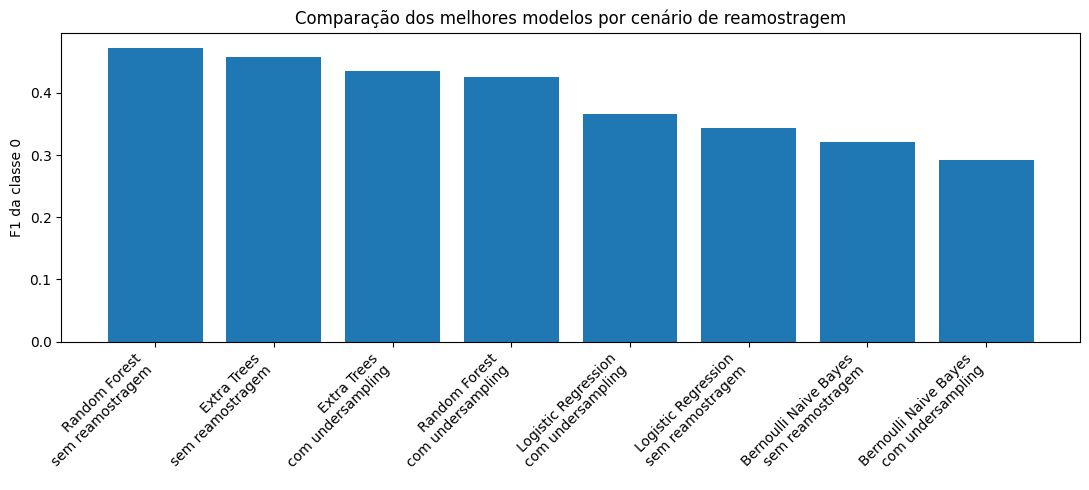

In [49]:
# @title Tunagem de Hiperparâmetros

best_by_model_variant = (
    validation_df
    .sort_values(["f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"], ascending=[False, True, False, False])
    .groupby(["modelo", "reamostragem"], as_index=False)
    .head(1)
    .sort_values(["f1_0", "taxa_concessao_indevida"], ascending=[False, True])
)

print("Melhor configuração por modelo e cenário de reamostragem, ainda com threshold 0.50:")
display(best_by_model_variant.round(4))

plot_df = best_by_model_variant[best_by_model_variant["modelo"] != "Dummy"].copy()
plot_df["configuracao"] = plot_df["modelo"] + "\n" + plot_df["reamostragem"]

plt.figure(figsize=(11, 5))
plt.bar(plot_df["configuracao"], plot_df["f1_0"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 da classe 0")
plt.title("Comparação dos melhores modelos por cenário de reamostragem")
plt.tight_layout()
plt.show()


### Escolha do melhor modelo na validação com ajuste de threshold

```text
modelo + reamostragem + hiperparâmetros + threshold
```

A regra de seleção prioriza `f1_0`, pois a classe `0` é a minoritária e representa acessos negados. Porém, para evitar que o modelo fique conservador demais e passe a negar muitos acessos legítimos, primeiro são consideradas apenas as combinações com `recall_1 >= 0.85`. Se nenhuma configuração atender a esse limite, o notebook usa a melhor configuração disponível e registra essa situação.

In [50]:
# busca de threshold para todas as configurações treinadas
threshold_tuning_results = []

for model_key, model in trained_models.items():
    model_name, variant_name, params_str = model_key
    proba_valid = get_proba_access(model, X_valid_enc)

    for threshold in THRESHOLDS:
        metrics = evaluate_predictions(y_valid, proba_valid, threshold=threshold)
        metrics.update({
            "modelo": model_name,
            "reamostragem": variant_name,
            "parametros": params_str,
        })
        threshold_tuning_results.append(metrics)

threshold_tuning_df = pd.DataFrame(threshold_tuning_results)
threshold_tuning_df["atende_recall_1_minimo"] = threshold_tuning_df["recall_1"] >= MIN_RECALL_CLASS_1

threshold_tuning_cols = [
    "modelo", "reamostragem", "parametros", "threshold", "atende_recall_1_minimo",
    "accuracy", "precision_0", "recall_0", "f1_0",
    "precision_1", "recall_1", "f1_1", "f1_macro",
    "auc_roc", "pr_auc_0", "taxa_concessao_indevida", "taxa_negacao_indevida",
    "negados_corretamente_tn", "concessoes_indevidas_fp", "negacoes_indevidas_fn", "concedidos_corretamente_tp",
]

threshold_tuning_df = threshold_tuning_df[threshold_tuning_cols].sort_values(
    ["atende_recall_1_minimo", "f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"],
    ascending=[False, False, True, False, False],
)

print(f"Top 20 combinações considerando hiperparâmetros e threshold, com preferência por recall_1 >= {MIN_RECALL_CLASS_1:.2f}:")
display(threshold_tuning_df.head(20).round(4))

# melhor configuração geral na validação
valid_candidates = threshold_tuning_df[threshold_tuning_df["atende_recall_1_minimo"]].copy()
if valid_candidates.empty:
    print(
        "Atenção: nenhuma configuração atingiu o recall mínimo da classe 1. "
        "A escolha será feita sem essa restrição."
    )
    valid_candidates = threshold_tuning_df.copy()

best_row = valid_candidates.sort_values(
    ["f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"],
    ascending=[False, True, False, False],
).iloc[0]

best_key = (best_row["modelo"], best_row["reamostragem"], best_row["parametros"])
best_model = trained_models[best_key]
chosen_threshold = float(best_row["threshold"])

print("Melhor combinação na validação:")
print(f"Modelo: {best_row['modelo']}")
print(f"Reamostragem: {best_row['reamostragem']}")
print(f"Parâmetros: {best_row['parametros']}")
print(f"Threshold: {chosen_threshold:.2f}")
print(f"Atende recall_1 mínimo: {bool(best_row['atende_recall_1_minimo'])}")
print(f"F1 da classe 0: {best_row['f1_0']:.4f}")
print(f"Recall da classe 1: {best_row['recall_1']:.4f}")
print(f"F1 macro: {best_row['f1_macro']:.4f}")
print(f"Taxa de concessão indevida: {best_row['taxa_concessao_indevida']:.4f}")


Top 20 combinações considerando hiperparâmetros e threshold, com preferência por recall_1 >= 0.85:


,modelo,reamostragem,parametros,threshold,atende_recall_1_minimo,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,negados_corretamente_tn,concessoes_indevidas_fp,negacoes_indevidas_fn,concedidos_corretamente_tp
1153,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.55,True,0.9469,0.5473,0.4683,0.5047,0.9677,0.9762,0.9719,0.7383,0.8357,0.3944,0.5317,0.0238,133,151,110,4521
706,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.60,True,0.9465,0.5425,0.4718,0.5047,0.9679,0.9756,0.9717,0.7382,0.8564,0.4420,0.5282,0.0244,134,150,113,4518
705,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.55,True,0.9497,0.5869,0.4401,0.5030,0.9662,0.9810,0.9735,0.7383,0.8564,0.4420,0.5599,0.0190,125,159,88,4543
692,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.60,True,0.9463,0.5407,0.4683,0.5019,0.9677,0.9756,0.9716,0.7367,0.8555,0.4368,0.5317,0.0244,133,151,113,4518
1186,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.80,True,0.9424,0.5018,0.4965,0.4991,0.9691,0.9698,0.9695,0.7343,0.8591,0.4230,0.5035,0.0302,141,143,140,4491
1139,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.55,True,0.9457,0.5341,0.4683,0.4991,0.9676,0.9750,0.9713,0.7352,0.8338,0.3910,0.5317,0.0250,133,151,116,4515
1172,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.80,True,0.9424,0.5018,0.4930,0.4973,0.9689,0.9700,0.9695,0.7334,0.8595,0.4215,0.5070,0.0300,140,144,139,4492
866,Random Forest,sem reamostragem,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.90,True,0.9296,0.4233,0.6021,0.4971,0.9750,0.9497,0.9622,0.7296,0.8539,0.4173,0.3979,0.0503,171,113,233,4398
1154,Extra Trees,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.60,True,0.9434,0.5112,0.4824,0.4964,0.9684,0.9717,0.9700,0.7332,0.8357,0.3944,0.5176,0.0283,137,147,131,4500
693,Random Forest,sem reamostragem,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.65,True,0.9422,0.5000,0.4894,0.4947,0.9687,0.9700,0.9694,0.7320,0.8555,0.4368,0.5106,0.0300,139,145,139,4492


Melhor combinação na validação:
Modelo: Extra Trees
Reamostragem: sem reamostragem
Parâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Threshold: 0.55
Atende recall_1 mínimo: True
F1 da classe 0: 0.5047
Recall da classe 1: 0.9762
F1 macro: 0.7383
Taxa de concessão indevida: 0.5317


### Análise do threshold do modelo escolhido

O threshold padrão `0.50` nem sempre é ideal em problemas desbalanceados. Como `P(ACTION=1)` representa a probabilidade de conceder acesso, aumentar o threshold torna o modelo mais conservador: ele só concede acesso quando está mais confiante.

A análise abaixo mostra o comportamento do **modelo vencedor** em diferentes thresholds. A escolha já foi feita na validação e será aplicada uma única vez no teste.

In [51]:
valid_proba_best = get_proba_access(best_model, X_valid_enc)

threshold_results = []
for threshold in THRESHOLDS:
    metrics = evaluate_predictions(y_valid, valid_proba_best, threshold=threshold)
    threshold_results.append(metrics)

threshold_df = pd.DataFrame(threshold_results)
threshold_df["atende_recall_1_minimo"] = threshold_df["recall_1"] >= MIN_RECALL_CLASS_1

threshold_display_cols = [
    "threshold", "atende_recall_1_minimo", "accuracy", "precision_0", "recall_0", "f1_0", "f1_macro",
    "precision_1", "recall_1", "auc_roc", "pr_auc_0", "taxa_concessao_indevida", "taxa_negacao_indevida",
    "concessoes_indevidas_fp", "negacoes_indevidas_fn",
]

print("Variação das métricas do modelo escolhido em diferentes thresholds:")
display(threshold_df[threshold_display_cols].round(4))


Variação das métricas do modelo escolhido em diferentes thresholds:


,threshold,atende_recall_1_minimo,accuracy,precision_0,recall_0,f1_0,f1_macro,precision_1,recall_1,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,concessoes_indevidas_fp,negacoes_indevidas_fn
0,0.30,True,0.9473,0.6033,0.2570,0.3605,0.6665,0.9560,0.9896,0.8357,0.3944,0.7430,0.0104,211,48
1,0.35,True,0.9502,0.6309,0.3310,0.4342,0.7041,0.9601,0.9881,0.8357,0.3944,0.6690,0.0119,190,55
2,0.40,True,0.9495,0.6169,0.3345,0.4338,0.7037,0.9603,0.9873,0.8357,0.3944,0.6655,0.0127,189,59
3,0.45,True,0.9493,0.6061,0.3521,0.4454,0.7094,0.9613,0.9860,0.8357,0.3944,0.6479,0.0140,184,65
4,0.50,True,0.9487,0.5889,0.3732,0.4569,0.7150,0.9624,0.9840,0.8357,0.3944,0.6268,0.0160,178,74
5,0.55,True,0.9469,0.5473,0.4683,0.5047,0.7383,0.9677,0.9762,0.8357,0.3944,0.5317,0.0238,151,110
6,0.60,True,0.9434,0.5112,0.4824,0.4964,0.7332,0.9684,0.9717,0.8357,0.3944,0.5176,0.0283,147,131
7,0.65,True,0.9400,0.4811,0.4930,0.4870,0.7275,0.9689,0.9674,0.8357,0.3944,0.5070,0.0326,144,151
8,0.70,True,0.9327,0.4315,0.5211,0.4721,0.7181,0.9703,0.9579,0.8357,0.3944,0.4789,0.0421,136,195
9,0.75,True,0.9278,0.4087,0.5599,0.4725,0.7169,0.9724,0.9503,0.8357,0.3944,0.4401,0.0497,125,230


In [52]:
chosen_threshold_row = threshold_df.loc[np.isclose(threshold_df["threshold"], chosen_threshold)].iloc[0]

print(f"Threshold escolhido na validação: {chosen_threshold:.2f}")
print("Métricas na validação com o threshold escolhido:")
display(chosen_threshold_row[threshold_display_cols].to_frame("valor").T.round(4))


Threshold escolhido na validação: 0.55
Métricas na validação com o threshold escolhido:


,threshold,atende_recall_1_minimo,accuracy,precision_0,recall_0,f1_0,f1_macro,precision_1,recall_1,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,concessoes_indevidas_fp,negacoes_indevidas_fn
valor,0.55,True,0.946897,0.547325,0.46831,0.504744,0.738344,0.96768,0.976247,0.835663,0.394448,0.53169,0.023753,151,110


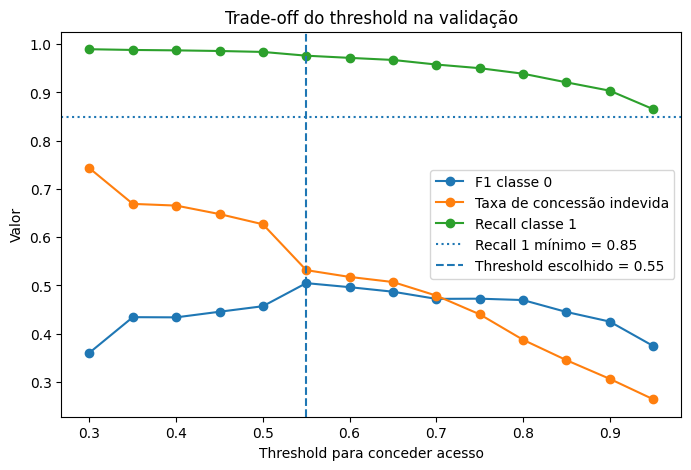

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1_0"], marker="o", label="F1 classe 0")
plt.plot(threshold_df["threshold"], threshold_df["taxa_concessao_indevida"], marker="o", label="Taxa de concessão indevida")
plt.plot(threshold_df["threshold"], threshold_df["recall_1"], marker="o", label="Recall classe 1")
plt.axhline(MIN_RECALL_CLASS_1, linestyle=":", label=f"Recall 1 mínimo = {MIN_RECALL_CLASS_1:.2f}")
plt.axvline(chosen_threshold, linestyle="--", label=f"Threshold escolhido = {chosen_threshold:.2f}")
plt.xlabel("Threshold para conceder acesso")
plt.ylabel("Valor")
plt.title("Trade-off do threshold na validação")
plt.legend()
plt.show()


Melhor resultado de cada modelo/cenário após tunagem de hiperparâmetros e threshold:


,modelo,reamostragem,threshold,atende_recall_1_minimo,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_macro,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,parametros
1153,Extra Trees,sem reamostragem,0.55,True,0.9469,0.5473,0.4683,0.5047,0.9677,0.9762,0.7383,0.8357,0.3944,0.5317,0.0238,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
706,Random Forest,sem reamostragem,0.60,True,0.9465,0.5425,0.4718,0.5047,0.9679,0.9756,0.7382,0.8564,0.4420,0.5282,0.0244,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
910,Random Forest,com undersampling,0.30,True,0.9347,0.4385,0.4648,0.4513,0.9671,0.9635,0.7083,0.8447,0.4235,0.5352,0.0365,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1360,Extra Trees,com undersampling,0.40,True,0.9111,0.3461,0.6056,0.4405,0.9746,0.9298,0.6961,0.8319,0.3264,0.3944,0.0702,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
316,Logistic Regression,sem reamostragem,0.70,True,0.9353,0.4397,0.4366,0.4382,0.9655,0.9659,0.7019,0.8412,0.3326,0.5634,0.0341,"{'C': 10.0, 'class_weight': None, 'penalty': '..."
535,Logistic Regression,com undersampling,0.45,True,0.9080,0.3091,0.4789,0.3757,0.9669,0.9344,0.6630,0.8248,0.3096,0.5211,0.0656,"{'C': 1.0, 'class_weight': None, 'penalty': 'l2'}"
1589,Bernoulli Naive Bayes,sem reamostragem,0.65,True,0.8655,0.2326,0.5775,0.3316,0.9715,0.8832,0.6284,0.8192,0.2384,0.4225,0.1168,"{'alpha': 0.01, 'fit_prior': True}"
1722,Bernoulli Naive Bayes,com undersampling,0.30,True,0.8383,0.2073,0.6373,0.3129,0.9745,0.8506,0.6106,0.8145,0.2423,0.3627,0.1494,"{'alpha': 0.01, 'fit_prior': True}"
0,Dummy,sem reamostragem,0.30,True,0.9422,0.0000,0.0000,0.0000,0.9422,1.0000,0.4851,0.5000,0.0578,1.0000,0.0000,{}


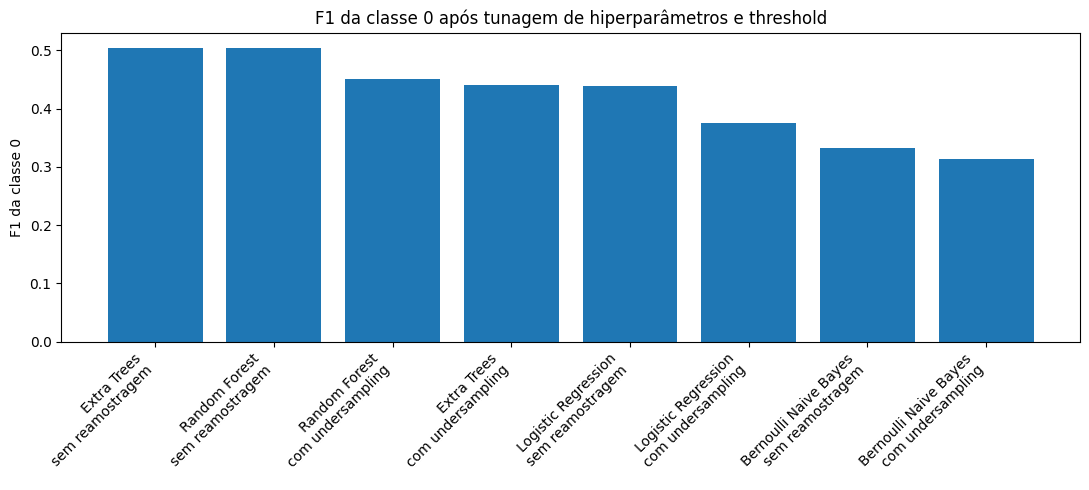

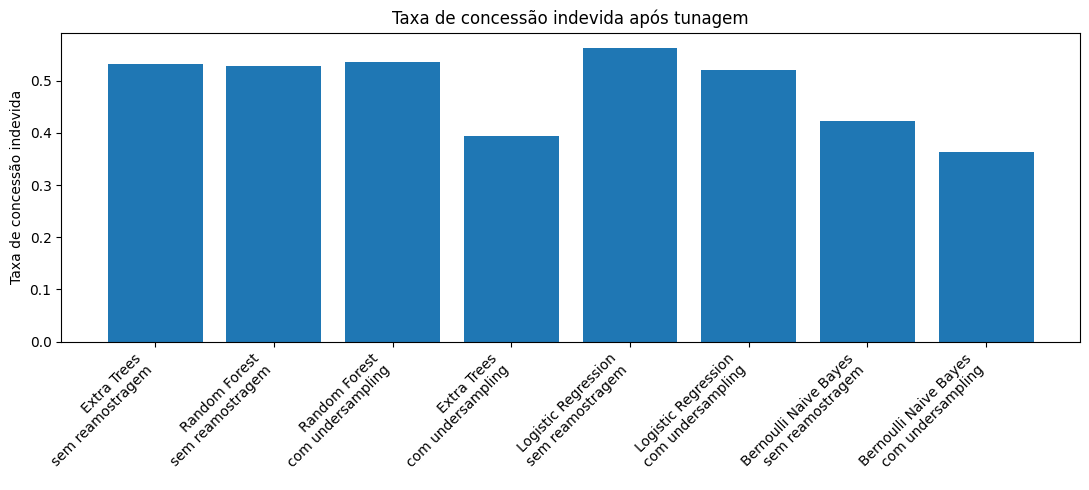

In [54]:
# @title Melhores modelos após ajuste de threshold

rows = []
for (model_name, variant_name), group in threshold_tuning_df.groupby(["modelo", "reamostragem"]):
    feasible = group[group["atende_recall_1_minimo"]].copy()
    if feasible.empty:
        feasible = group.copy()
    selected = feasible.sort_values(
        ["f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"],
        ascending=[False, True, False, False],
    ).iloc[0]
    rows.append(selected)

best_tuned_by_model = (
    pd.DataFrame(rows)
    .sort_values(["f1_0", "taxa_concessao_indevida", "f1_macro", "auc_roc"], ascending=[False, True, False, False])
)

print("Melhor resultado de cada modelo/cenário após tunagem de hiperparâmetros e threshold:")
display(best_tuned_by_model[[
    "modelo", "reamostragem", "threshold", "atende_recall_1_minimo",
    "accuracy", "precision_0", "recall_0", "f1_0", "precision_1", "recall_1",
    "f1_macro", "auc_roc", "pr_auc_0", "taxa_concessao_indevida", "taxa_negacao_indevida", "parametros"
]].round(4))

plot_df = best_tuned_by_model[best_tuned_by_model["modelo"] != "Dummy"].copy()
plot_df["configuracao"] = plot_df["modelo"] + "\n" + plot_df["reamostragem"]

plt.figure(figsize=(11, 5))
plt.bar(plot_df["configuracao"], plot_df["f1_0"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 da classe 0")
plt.title("F1 da classe 0 após tunagem de hiperparâmetros e threshold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["configuracao"], plot_df["taxa_concessao_indevida"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Taxa de concessão indevida")
plt.title("Taxa de concessão indevida após tunagem")
plt.tight_layout()
plt.show()


### Avaliação final no conjunto de teste

Agora o modelo e o threshold já foram escolhidos. O conjunto de teste é usado apenas uma vez para estimar o desempenho final.


In [55]:
test_proba = get_proba_access(best_model, X_test_enc)
test_metrics_default = evaluate_predictions(y_test, test_proba, threshold=0.50)
test_metrics_chosen = evaluate_predictions(y_test, test_proba, threshold=chosen_threshold)

final_test_df = pd.DataFrame([
    {"avaliacao": "teste_threshold_0.50", **test_metrics_default},
    {"avaliacao": f"teste_threshold_{chosen_threshold:.2f}", **test_metrics_chosen},
])

final_cols = [
    "avaliacao", "threshold", "accuracy", "precision_0", "recall_0", "f1_0", "f1_macro",
    "auc_roc", "pr_auc_0", "taxa_concessao_indevida", "taxa_negacao_indevida",
    "negados_corretamente_tn", "concessoes_indevidas_fp", "negacoes_indevidas_fn", "concedidos_corretamente_tp",
]

display(final_test_df[final_cols].round(4))


,avaliacao,threshold,accuracy,precision_0,recall_0,f1_0,f1_macro,auc_roc,pr_auc_0,taxa_concessao_indevida,taxa_negacao_indevida,negados_corretamente_tn,concessoes_indevidas_fp,negacoes_indevidas_fn,concedidos_corretamente_tp
0,teste_threshold_0.50,0.50,0.9447,0.5367,0.3333,0.4113,0.6911,0.8189,0.355,0.6667,0.0177,95,190,82,4549
1,teste_threshold_0.55,0.55,0.9412,0.4915,0.4070,0.4453,0.7071,0.8189,0.355,0.5930,0.0259,116,169,120,4511


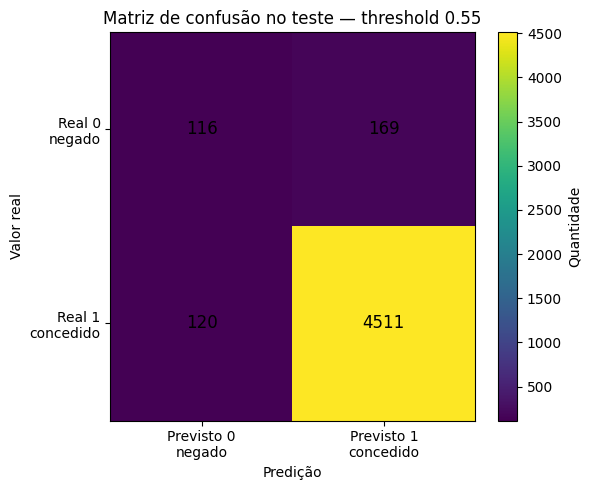

              precision    recall  f1-score   support

    negado_0       0.49      0.41      0.45       285
 concedido_1       0.96      0.97      0.97      4631

    accuracy                           0.94      4916
   macro avg       0.73      0.69      0.71      4916
weighted avg       0.94      0.94      0.94      4916



In [56]:
y_test_pred = (test_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect="auto")
plt.colorbar(label="Quantidade")
plt.xticks([0, 1], ["Previsto 0\nnegado", "Previsto 1\nconcedido"])
plt.yticks([0, 1], ["Real 0\nnegado", "Real 1\nconcedido"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)
plt.title(f"Matriz de confusão no teste — threshold {chosen_threshold:.2f}")
plt.xlabel("Predição")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred, target_names=["negado_0", "concedido_1"], zero_division=0))


### Interpretação do modelo

A interpretação abaixo mostra quais variáveis codificadas tiveram maior peso/importância para o melhor modelo. Isso ajuda a explicar quais padrões foram mais relevantes para a classificação.


In [57]:
def get_feature_names_from_preprocessor(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        # Compatibilidade com versões antigas do scikit-learn
        ohe = preprocessor.named_transformers_["categorical"].named_steps["onehot"]
        try:
            return ohe.get_feature_names_out(categorical_features)
        except Exception:
            return np.array([f"feature_{i}" for i in range(X_train_enc.shape[1])])

feature_names = get_feature_names_from_preprocessor(preprocessor)

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
    interpretation_df = pd.DataFrame({
        "feature_codificada": feature_names,
        "importancia": importance,
    }).sort_values("importancia", ascending=False).head(20)

elif hasattr(best_model, "coef_"):
    coef = best_model.coef_[0]
    interpretation_df = pd.DataFrame({
        "feature_codificada": feature_names,
        "coeficiente": coef,
        "abs_coeficiente": np.abs(coef),
    }).sort_values("abs_coeficiente", ascending=False).head(20)

else:
    interpretation_df = pd.DataFrame({
        "observacao": ["O modelo escolhido não possui atributo direto de importância ou coeficientes."]
    })

display(interpretation_df)


,feature_codificada,importancia
355,categorical__RESOURCE_infrequent_sklearn,0.045610
2088,categorical__ROLE_FAMILY_DESC_infrequent_sklearn,0.016297
1065,categorical__MGR_ID_infrequent_sklearn,0.015063
2657,categorical__RESOURCE__ROLE_CODE_infrequent_sk...,0.011387
1784,categorical__ROLE_FAMILY_DESC_117906,0.010674
1395,categorical__ROLE_DEPTNAME_118992,0.008506
105,categorical__RESOURCE_20897,0.008327
1230,categorical__ROLE_ROLLUP_2_118343,0.006112
164,categorical__RESOURCE_32270,0.005815
1590,categorical__ROLE_DEPTNAME_infrequent_sklearn,0.005698


## **4. Conclusão**

O projeto confirma que a base é fortemente desbalanceada, com predominância de acessos concedidos. Por isso, modelos avaliados apenas por acurácia podem parecer bons mesmo quando falham na identificação da classe minoritária.

A estratégia adotada priorizou uma metodologia segura contra vazamento de dados: separação estratificada antes do pré-processamento, codificação ajustada apenas no treino, reamostragem aplicada somente no treino, seleção de modelo na validação e avaliação final apenas no teste.

Nesta versão, a etapa de modelagem foi reforçada com uma **grade ampliada de hiperparâmetros**. Foram testadas penalizações `l1` e `l2`, diferentes valores de `C` e `class_weight` para Regressão Logística; `n_estimators`, `max_depth`, `min_samples_leaf` e `max_features` para modelos de árvores; e valores de suavização `alpha` para Bernoulli Naive Bayes. Além disso, o threshold passou a ser comparado para todas as combinações de modelo, reamostragem e hiperparâmetros.

A principal implicação prática é que, em sistemas de controle de acesso, falsos positivos da classe `1` representam concessões indevidas. Portanto, a escolha do threshold deve considerar o custo de segurança de conceder acesso a quem deveria ser negado, sem ignorar o impacto de negar acessos legítimos. Por isso, a regra final prioriza `f1_0`, mas tenta manter `recall_1 >= 0.85`.

A análise de dados faltantes e outliers também foi ajustada ao tipo do dataset: como não há grandezas contínuas relevantes, outliers foram tratados como **categorias raras**; e como os atributos são categóricos, ausências são representadas por um token constante em vez de média ou mediana. O `min_frequency` do `OneHotEncoder` reduz ruído e dimensionalidade ao agrupar categorias pouco frequentes.

### Limitações

- O dataset contém principalmente identificadores categóricos, o que limita interpretações sem conhecimento de domínio.
- A alta cardinalidade pode gerar muitas categorias raras.
- O desbalanceamento dificulta a identificação da classe `0`.
- O dataset não contém atributos sensíveis ou contexto organizacional completo, então não é possível avaliar justiça entre grupos sociais.
- O custo real de uma concessão indevida versus uma negação indevida não foi fornecido; por isso, a escolha de threshold foi baseada em métricas técnicas.
- A tunagem foi ampliada, mas ainda foi mantida em uma grade controlada para viabilizar execução em Google Colab.

### Trabalhos futuros

- testar target encoding com validação cruzada;
- aplicar calibração de probabilidades;
- usar validação cruzada estratificada para estimativas mais estáveis;
- avaliar diferentes custos para falsos positivos e falsos negativos;
- testar estratégias de target encoding evitando vazamento de dados.

In [58]:
# @title Exportar resultados do projeto

import os
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

BASE_DIR = Path("entrega_resultados")
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def salvar_df(nome_arquivo, objeto):
    """Salva DataFrame se ele existir."""
    if objeto in globals():
        df_obj = globals()[objeto]
        if isinstance(df_obj, pd.DataFrame):
            caminho = RESULTS_DIR / nome_arquivo
            df_obj.to_csv(caminho, index=False, encoding="utf-8-sig")
            print(f"Salvo: {caminho}")
        else:
            print(f"Aviso: {objeto} existe, mas não é DataFrame.")
    else:
        print(f"Aviso: {objeto} não encontrado. Pulando {nome_arquivo}.")


def converter_json_seguro(valor):
    """Converte tipos numpy/pandas para JSON."""
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    if isinstance(valor, (np.ndarray,)):
        return valor.tolist()
    if pd.isna(valor) if not isinstance(valor, (dict, list, tuple, str)) else False:
        return None
    return valor


# 1. Salvar tabelas principais
salvar_df("01_resultados_validacao_threshold_050.csv", "validation_df")
salvar_df("02_tunagem_threshold_todos_modelos.csv", "threshold_tuning_df")
salvar_df("03_melhores_modelos_tunados.csv", "best_tuned_by_model")
salvar_df("04_threshold_modelo_escolhido.csv", "threshold_df")
salvar_df("05_resultado_final_teste.csv", "final_test_df")
salvar_df("06_importancia_ou_coeficientes_features.csv", "interpretation_df")
salvar_df("07_resumo_split_treino_validacao_teste.csv", "split_summary")


# 2. Salvar matriz de confusão e relatório de classificação
if "y_test" in globals() and "test_proba" in globals() and "chosen_threshold" in globals():
    y_test_pred_export = (test_proba >= chosen_threshold).astype(int)
    cm_export = confusion_matrix(y_test, y_test_pred_export, labels=[0, 1])

    cm_df = pd.DataFrame(
        cm_export,
        index=["real_0_negado", "real_1_concedido"],
        columns=["previsto_0_negado", "previsto_1_concedido"]
    )
    cm_df.to_csv(RESULTS_DIR / "08_matriz_confusao_teste.csv", encoding="utf-8-sig")
    print(f"Salvo: {RESULTS_DIR / '08_matriz_confusao_teste.csv'}")

    report_txt = classification_report(
        y_test,
        y_test_pred_export,
        target_names=["negado_0", "concedido_1"],
        zero_division=0
    )

    with open(RESULTS_DIR / "09_classification_report_teste.txt", "w", encoding="utf-8") as f:
        f.write(report_txt)

    print(f"Salvo: {RESULTS_DIR / '09_classification_report_teste.txt'}")

else:
    print("Aviso: y_test, test_proba ou chosen_threshold não encontrados. Matriz de confusão não foi salva.")


# 3. Salvar resumo textual do projeto
if "summary_lines" in globals():
    with open(RESULTS_DIR / "10_resumo_projeto.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(summary_lines))
    print(f"Salvo: {RESULTS_DIR / '10_resumo_projeto.txt'}")
else:
    print("Aviso: summary_lines não encontrado. Resumo textual não foi salvo.")


# 4. Salvar melhor modelo/threshold/hiperparâmetros em JSON
melhor_modelo_info = {}

if "best_row" in globals():
    melhor_modelo_info.update({
        "modelo": best_row.get("modelo", None),
        "reamostragem": best_row.get("reamostragem", None),
        "parametros": best_row.get("parametros", None),
        "threshold": best_row.get("threshold", None),
        "accuracy_validacao": best_row.get("accuracy", None),
        "precision_0_validacao": best_row.get("precision_0", None),
        "recall_0_validacao": best_row.get("recall_0", None),
        "f1_0_validacao": best_row.get("f1_0", None),
        "f1_macro_validacao": best_row.get("f1_macro", None),
        "auc_roc_validacao": best_row.get("auc_roc", None),
        "pr_auc_0_validacao": best_row.get("pr_auc_0", None),
        "taxa_concessao_indevida_validacao": best_row.get("taxa_concessao_indevida", None),
    })

if "chosen_threshold" in globals():
    melhor_modelo_info["threshold_escolhido"] = chosen_threshold

if "test_metrics_chosen" in globals():
    for chave, valor in test_metrics_chosen.items():
        melhor_modelo_info[f"{chave}_teste"] = valor

with open(RESULTS_DIR / "11_melhor_modelo_final.json", "w", encoding="utf-8") as f:
    json.dump(
        melhor_modelo_info,
        f,
        ensure_ascii=False,
        indent=4,
        default=converter_json_seguro
    )

print(f"Salvo: {RESULTS_DIR / '11_melhor_modelo_final.json'}")


# 5. Salvar gráficos principais

# Gráfico 1 — Distribuição da variável alvo
if "df" in globals() and "TARGET_COL" in globals():
    plt.figure(figsize=(6, 4))
    df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
    plt.title("Distribuição da variável alvo ACTION")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks([0, 1], ["0 - Negado", "1 - Concedido"], rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_distribuicao_classes.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '01_distribuicao_classes.png'}")


# Gráfico 2 — Cardinalidade das features
if "cardinality" in globals():
    plt.figure(figsize=(9, 5))
    plt.barh(cardinality["feature"], cardinality["valores_unicos"])
    plt.gca().invert_yaxis()
    plt.title("Cardinalidade das features categóricas")
    plt.xlabel("Quantidade de categorias distintas")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_cardinalidade_features.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '02_cardinalidade_features.png'}")


# Gráfico 3 — Curva de threshold do modelo escolhido
if "threshold_df" in globals() and "chosen_threshold" in globals():
    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["f1_0"], marker="o", label="F1 classe 0")
    plt.plot(
        threshold_df["threshold"],
        threshold_df["taxa_concessao_indevida"],
        marker="o",
        label="Taxa de concessão indevida"
    )
    plt.plot(threshold_df["threshold"], threshold_df["recall_1"], marker="o", label="Recall classe 1")

    if "MIN_RECALL_CLASS_1" in globals():
        plt.axhline(
            MIN_RECALL_CLASS_1,
            linestyle=":",
            label=f"Recall 1 mínimo = {MIN_RECALL_CLASS_1:.2f}"
        )

    plt.axvline(chosen_threshold, linestyle="--", label=f"Threshold escolhido = {chosen_threshold:.2f}")
    plt.xlabel("Threshold para conceder acesso")
    plt.ylabel("Valor")
    plt.title("Trade-off do threshold na validação")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_curva_threshold_modelo_escolhido.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '03_curva_threshold_modelo_escolhido.png'}")


# Gráfico 4 — Comparação F1 classe 0 por modelo
if "best_tuned_by_model" in globals():
    plot_df_export = best_tuned_by_model[best_tuned_by_model["modelo"] != "Dummy"].copy()
    plot_df_export["configuracao"] = plot_df_export["modelo"] + "\n" + plot_df_export["reamostragem"]

    plt.figure(figsize=(11, 5))
    plt.bar(plot_df_export["configuracao"], plot_df_export["f1_0"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("F1 da classe 0")
    plt.title("F1 da classe 0 após tunagem de hiperparâmetros e threshold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_comparacao_f1_classe_0.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '04_comparacao_f1_classe_0.png'}")

    plt.figure(figsize=(11, 5))
    plt.bar(plot_df_export["configuracao"], plot_df_export["taxa_concessao_indevida"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Taxa de concessão indevida")
    plt.title("Taxa de concessão indevida após tunagem")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_comparacao_concessao_indevida.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '05_comparacao_concessao_indevida.png'}")


# Gráfico 5 — Matriz de confusão final
if "y_test" in globals() and "test_proba" in globals() and "chosen_threshold" in globals():
    y_test_pred_export = (test_proba >= chosen_threshold).astype(int)
    cm_export = confusion_matrix(y_test, y_test_pred_export, labels=[0, 1])

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_export, aspect="auto")
    plt.colorbar(label="Quantidade")
    plt.xticks([0, 1], ["Previsto 0\nnegado", "Previsto 1\nconcedido"])
    plt.yticks([0, 1], ["Real 0\nnegado", "Real 1\nconcedido"])

    for i in range(cm_export.shape[0]):
        for j in range(cm_export.shape[1]):
            plt.text(j, i, str(cm_export[i, j]), ha="center", va="center", fontsize=12)

    plt.title(f"Matriz de confusão no teste — threshold {chosen_threshold:.2f}")
    plt.xlabel("Predição")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_matriz_confusao_teste.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Salvo: {FIGURES_DIR / '06_matriz_confusao_teste.png'}")


# 6. Criar ZIP e baixar
zip_path = shutil.make_archive("entrega_resultados_projeto_am_tema2", "zip", BASE_DIR)

print("\nArquivo ZIP criado:")
print(zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Download automático disponível apenas no Google Colab.")
    print(f"Baixe manualmente o arquivo: {zip_path}")

Salvo: entrega_resultados/results/01_resultados_validacao_threshold_050.csv
Salvo: entrega_resultados/results/02_tunagem_threshold_todos_modelos.csv
Salvo: entrega_resultados/results/03_melhores_modelos_tunados.csv
Salvo: entrega_resultados/results/04_threshold_modelo_escolhido.csv
Salvo: entrega_resultados/results/05_resultado_final_teste.csv
Salvo: entrega_resultados/results/06_importancia_ou_coeficientes_features.csv
Salvo: entrega_resultados/results/07_resumo_split_treino_validacao_teste.csv
Salvo: entrega_resultados/results/08_matriz_confusao_teste.csv
Salvo: entrega_resultados/results/09_classification_report_teste.txt
Salvo: entrega_resultados/results/10_resumo_projeto.txt
Salvo: entrega_resultados/results/11_melhor_modelo_final.json
Salvo: entrega_resultados/figures/01_distribuicao_classes.png
Salvo: entrega_resultados/figures/02_cardinalidade_features.png
Salvo: entrega_resultados/figures/03_curva_threshold_modelo_escolhido.png
Salvo: entrega_resultados/figures/04_comparacao_f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>